In [144]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import json
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL

In [5]:
taxi_df = pd.read_csv('~/Desktop/HSE_mag/Magister/Data/NAB/data/realKnownCause/nyc_taxi.csv')
ambient_temp_df = pd.read_csv('~/Desktop/HSE_mag/Magister/Data/NAB/data/realKnownCause/ambient_temperature_system_failure.csv')
cpu_df = pd.read_csv('~/Desktop/HSE_mag/Magister/Data/NAB/data/realKnownCause/cpu_utilization_asg_misconfiguration.csv')

## Набор данных: количество пассажиров нью-йоркских такси 

In [10]:
taxi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10320 entries, 0 to 10319
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  10320 non-null  object
 1   value      10320 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 161.4+ KB


In [14]:
#Приведем колонки к timestamp
taxi_df['timestamp'] = pd.to_datetime(taxi_df['timestamp'])

In [92]:
#добавим labels
with open('/Users/dmitry/Desktop/HSE_mag/Magister/Data/NAB/labels/combined_labels.json') as f:
    labels = json.load(f)

labels['realKnownCause/nyc_taxi.csv'].append(taxi_df['timestamp'].iloc[-1])

taxi_df['anomaly'] = 0

for i in range(0, len(labels['realKnownCause/nyc_taxi.csv']) - 1, 2):
    start = labels['realKnownCause/nyc_taxi.csv'][i]
    end = labels['realKnownCause/nyc_taxi.csv'][i+1]

    mask = ((taxi_df['timestamp'] <= end) & (taxi_df['timestamp'] >= start))
    taxi_df.loc[mask, 'anomaly'] = 1
    
        

In [93]:
print(f'Процент аномалий в датасэте {np.round(taxi_df['anomaly'].sum() / taxi_df.shape[0] * 100, 2)} %')

Процент аномалий в датасэте 17.35 %


In [104]:
taxi_df.describe()

,timestamp,value,anomaly
count,10320,10320.000000,10320.000000
mean,2014-10-16 11:45:00,15137.569380,0.173547
min,2014-07-01 00:00:00,8.000000,0.000000
25%,2014-08-23 17:52:30,10262.000000,0.000000
50%,2014-10-16 11:45:00,16778.000000,0.000000
75%,2014-12-09 05:37:30,19838.750000,0.000000
max,2015-01-31 23:30:00,39197.000000,1.000000
std,NaN,6939.495808,0.378737


In [107]:
taxi_df.duplicated().sum()

0

Анализ показал отсутствие пропусков, дублирующихся временных отметок и нарушений порядка наблюдений. Временной шаг является равномерным, что позволяет применять методы сезонной декомпозиции без дополнительной интерполяции.

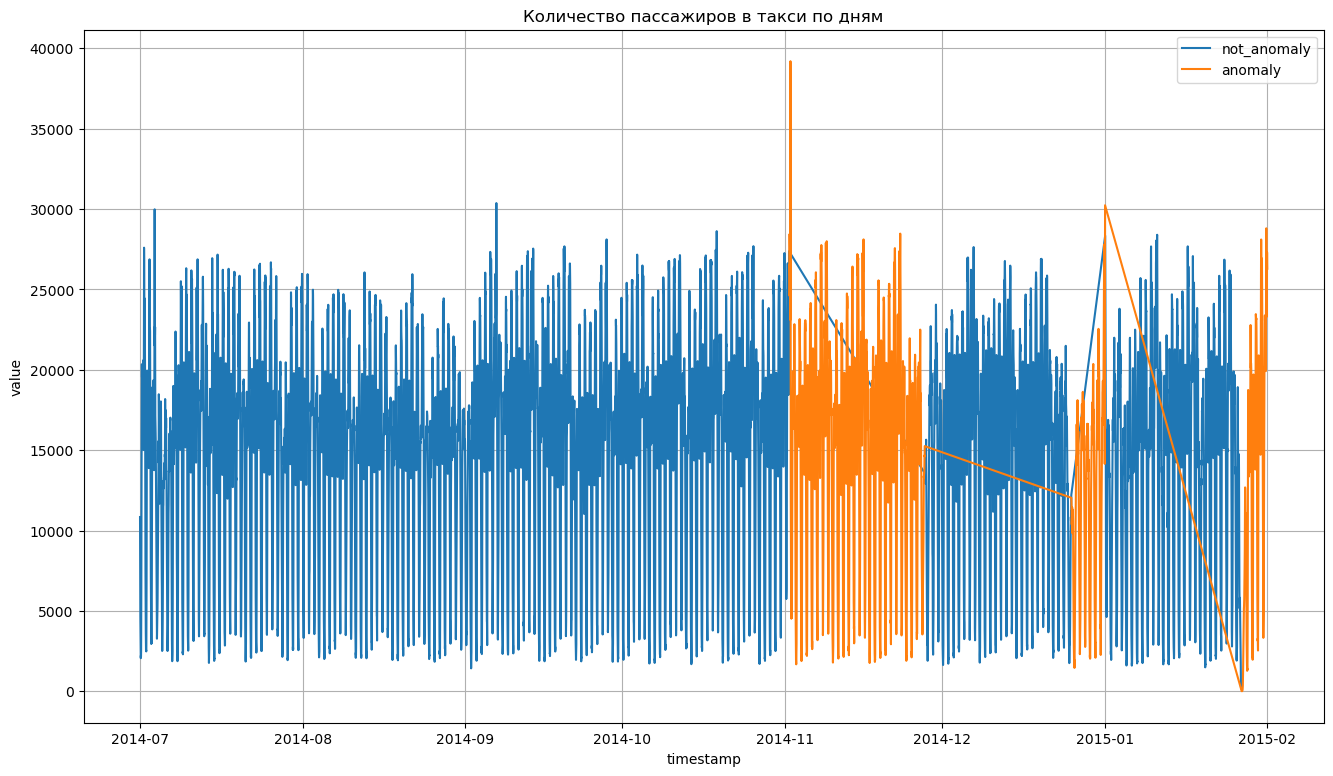

In [197]:
plt.figure(figsize=(16,9))

plt.title('Количество пассажиров в такси по дням')
sns.lineplot(taxi_df.loc[taxi_df['anomaly'] == 0], y = 'value', x= 'timestamp', label = 'not_anomaly')
sns.lineplot(taxi_df.loc[taxi_df['anomaly'] != 0], y = 'value', x= 'timestamp', label = 'anomaly')
plt.grid()
plt.show()

Визуальный анализ ряда показывает наличие повторяющегося поведения, что указывает на сезонную компоненту. При этом уровень и амплитуда колебаний могут меняться во времени, из-за чего фиксированный порог для всего ряда потенциально приводит либо к ложным срабатываниям, либо к пропуску аномалий.

In [129]:
[x for x in range(10)]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

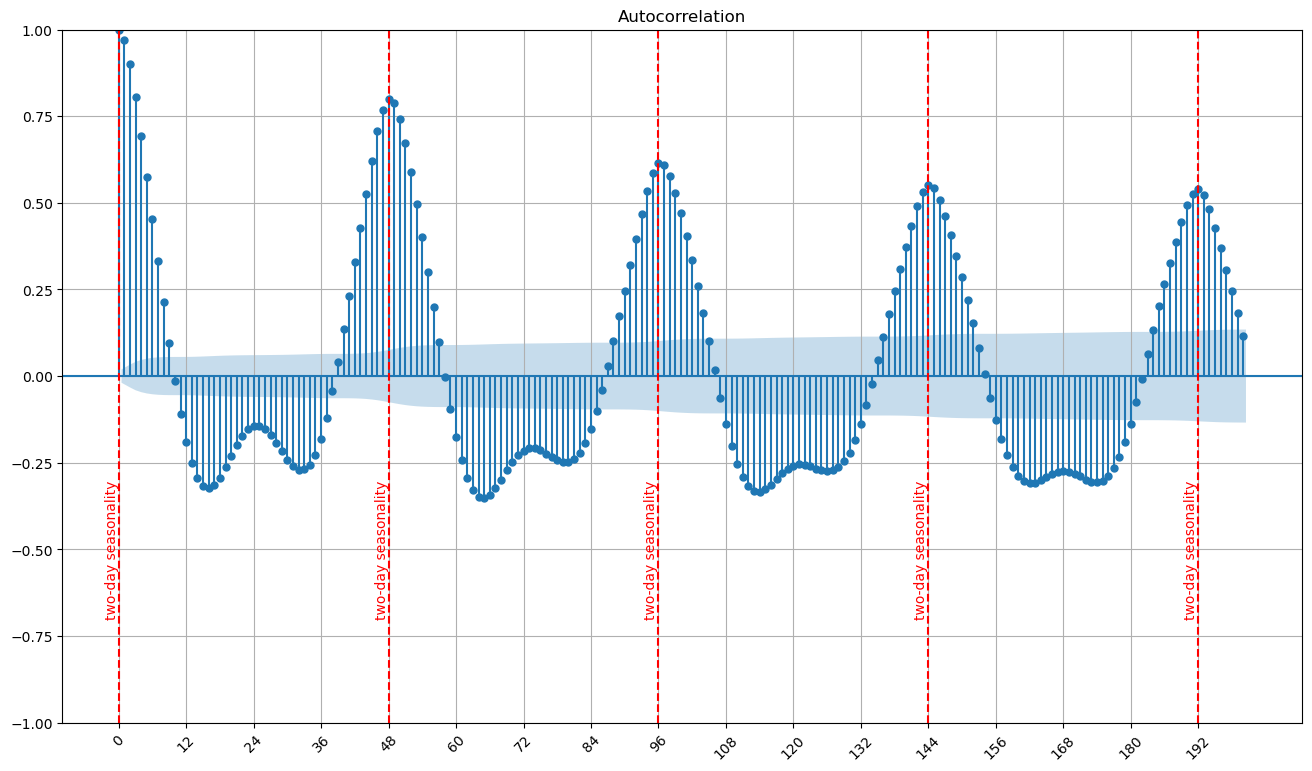

In [140]:
fig, ax = plt.subplots(figsize=(16, 9))
plot_acf(taxi_df["value"], lags=200, ax=ax)

ax.set_xticks(range(0, 201, 12))
ax.tick_params(axis='x', rotation=45)
ax.grid(True)
lags = [x for x in range(0,201, 48)]
for lag in lags:
    ax.axvline(x=lag, color='red', linestyle='--', linewidth=1.5, label = 'season_component')
    ax.text(
        lag, 
        -0.5, 
        'two-day seasonality',
        rotation=90,
        color='red',
        ha='right',
        va='center'
    )

plt.show()

В этом наборе данных наблюдаем 48 часовую сезонность 

Для выделения сезонной и трендовой составляющих временного ряда использована STL-декомпозиция (Seasonal-Trend decomposition using Loess). Метод позволяет представить наблюдаемый ряд в виде суммы тренда, сезонной компоненты и остатка. В рамках исследования STL применяется для удаления регулярной структуры ряда перед последующей оценкой аномальности наблюдений. Анализ остатков после декомпозиции позволяет выявлять отклонения, не объясняемые нормальной сезонной динамикой.

In [163]:
#Применим STL разложение
stl = STL(taxi_df["value"], period=48, robust = True)
result = stl.fit()
taxi_df["trend"] = result.trend
taxi_df["seasonal"] = result.seasonal
taxi_df["resid"] = result.resid

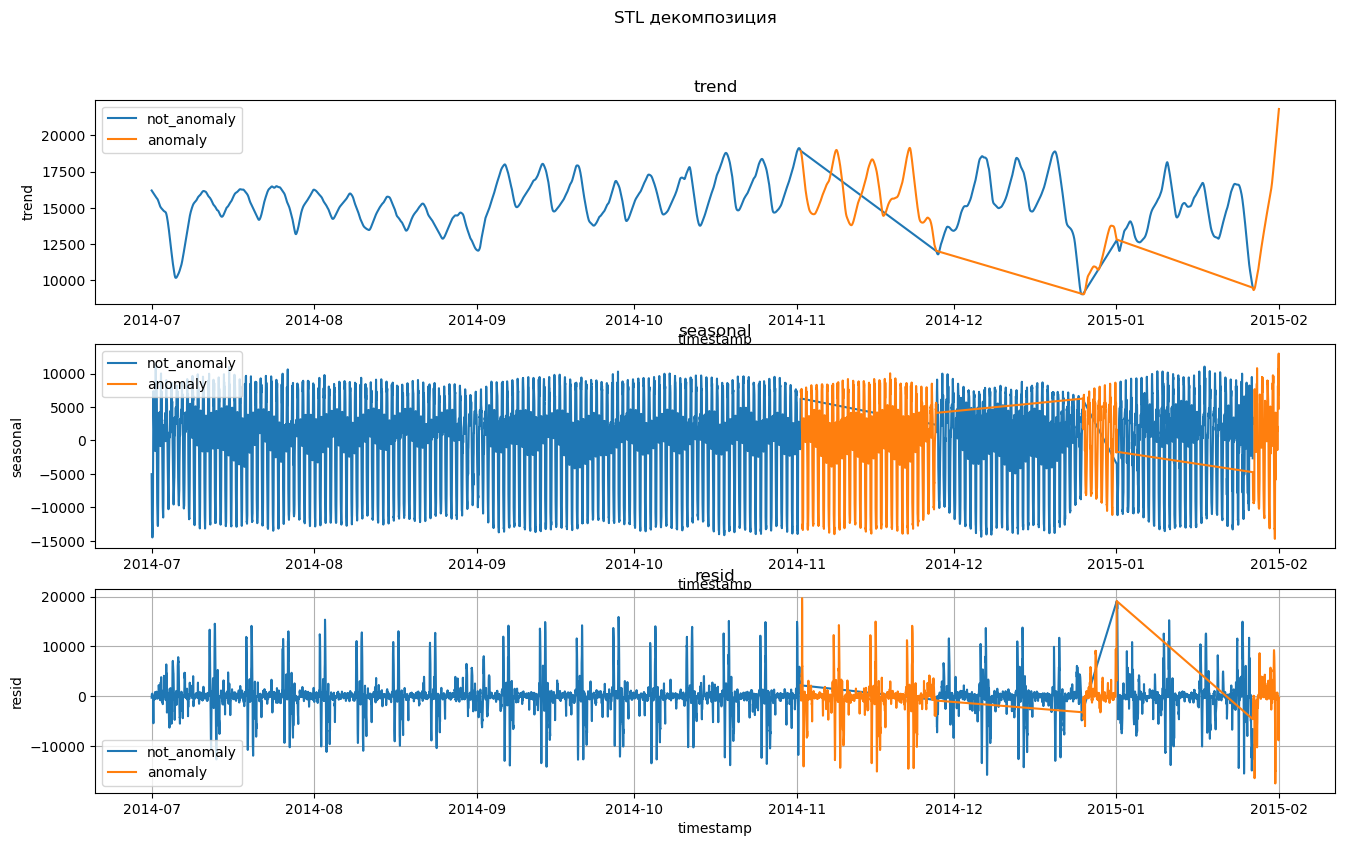

In [203]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9))
plt.suptitle('STL декомпозиция')
for ax, name in zip(axes, ['trend', 'seasonal', 'resid']):
    ax.set_title(name)
    sns.lineplot(taxi_df.loc[taxi_df['anomaly'] == 0], x = 'timestamp', y = name, label = 'not_anomaly', ax = ax)
    sns.lineplot(taxi_df.loc[taxi_df['anomaly'] != 0], x = 'timestamp', y = name, label = 'anomaly', ax = ax)
plt.legend()
plt.grid()

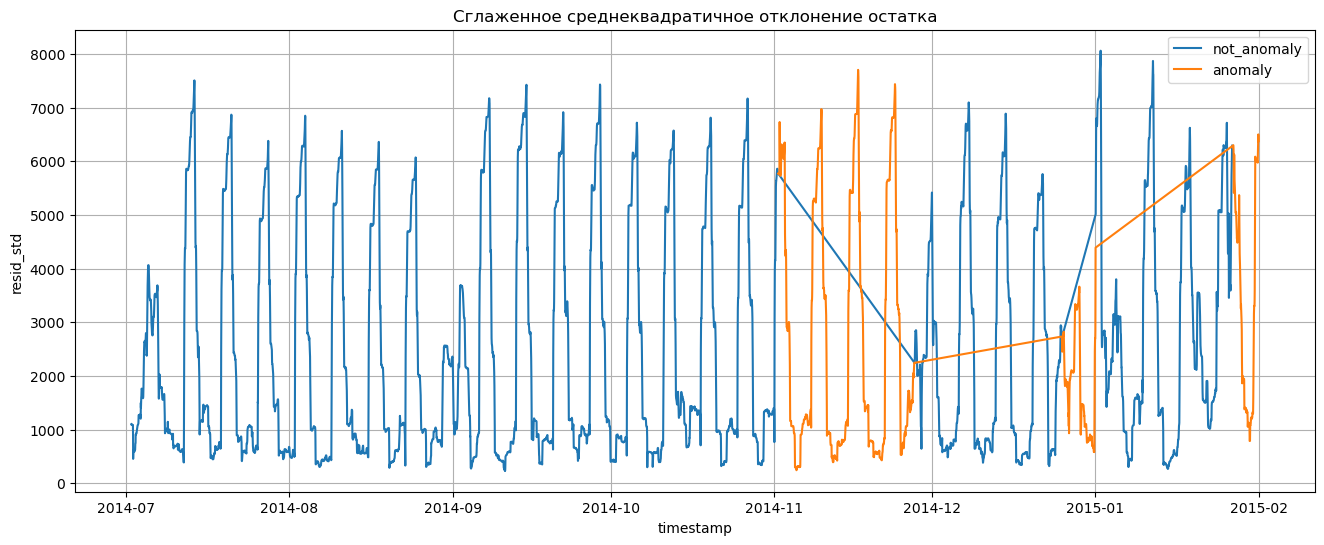

In [207]:
taxi_df["resid_std"] = taxi_df["resid"].rolling(48).std()

plt.figure(figsize=(16,6))
plt.title('Сглаженное среднеквадратичное отклонение остатка')
sns.lineplot(taxi_df.loc[taxi_df['anomaly'] ==0], x = 'timestamp', y = 'resid_std', label = 'not_anomaly')
sns.lineplot(taxi_df.loc[taxi_df['anomaly'] ==1], x = 'timestamp', y = 'resid_std', label = 'anomaly')
plt.grid()
plt.show()

В ходе анализа было выявлено, что остаточная компонента после STL-декомпозиции не всегда содержит явно выраженные точечные выбросы, соответствующие аномалиям. Это связано с тем, что аномалии в рассматриваемом наборе данных носят интервальный характер и проявляются как изменение структуры распределения, а не как одиночные экстремальные значения. В частности, в аномальных периодах наблюдается увеличение дисперсии и сдвиг пика на начало месяца. Данное наблюдение подтверждает необходимость использования адаптивных методов пороговой детекции, учитывающих локальные характеристики временного ряда.

## Набор данных: температура окружающей среды в офисе.

In [209]:
ambient_temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  7267 non-null   object 
 1   value      7267 non-null   float64
dtypes: float64(1), object(1)
memory usage: 113.7+ KB


In [211]:
#Приведем колонки к timestamp
ambient_temp_df['timestamp'] = pd.to_datetime(ambient_temp_df['timestamp'])

In [221]:
#добавим labels
with open('/Users/dmitry/Desktop/HSE_mag/Magister/Data/NAB/labels/combined_labels.json') as f:
    labels = json.load(f)

labels['realKnownCause/ambient_temperature_system_failure.csv']

ambient_temp_df['anomaly'] = 0

for i in range(0, len(labels['realKnownCause/ambient_temperature_system_failure.csv']) - 1, 2):
    start = labels['realKnownCause/ambient_temperature_system_failure.csv'][i]
    end = labels['realKnownCause/ambient_temperature_system_failure.csv'][i+1]

    mask = ((ambient_temp_df['timestamp'] <= end) & (ambient_temp_df['timestamp'] >= start))
    ambient_temp_df.loc[mask, 'anomaly'] = 1
    
        

In [224]:
print(f'Процент аномалий в датасэте {np.round(ambient_temp_df['anomaly'].sum() / ambient_temp_df.shape[0] * 100, 2)} %')

Процент аномалий в датасэте 33.85 %


In [225]:
ambient_temp_df.describe()

,timestamp,value,anomaly
count,7267,7267.000000,7267.000000
mean,2013-12-17 01:43:01.477914112,71.242433,0.338517
min,2013-07-04 00:00:00,57.458406,0.000000
25%,2013-10-01 13:30:00,68.369411,0.000000
50%,2013-12-19 04:00:00,71.858493,0.000000
75%,2014-03-06 01:30:00,74.430958,1.000000
max,2014-05-28 15:00:00,86.223213,1.000000
std,NaN,4.247509,0.473238


In [226]:
taxi_df.duplicated().sum()

0

В данном датасэте также проблем с данными не выявлено

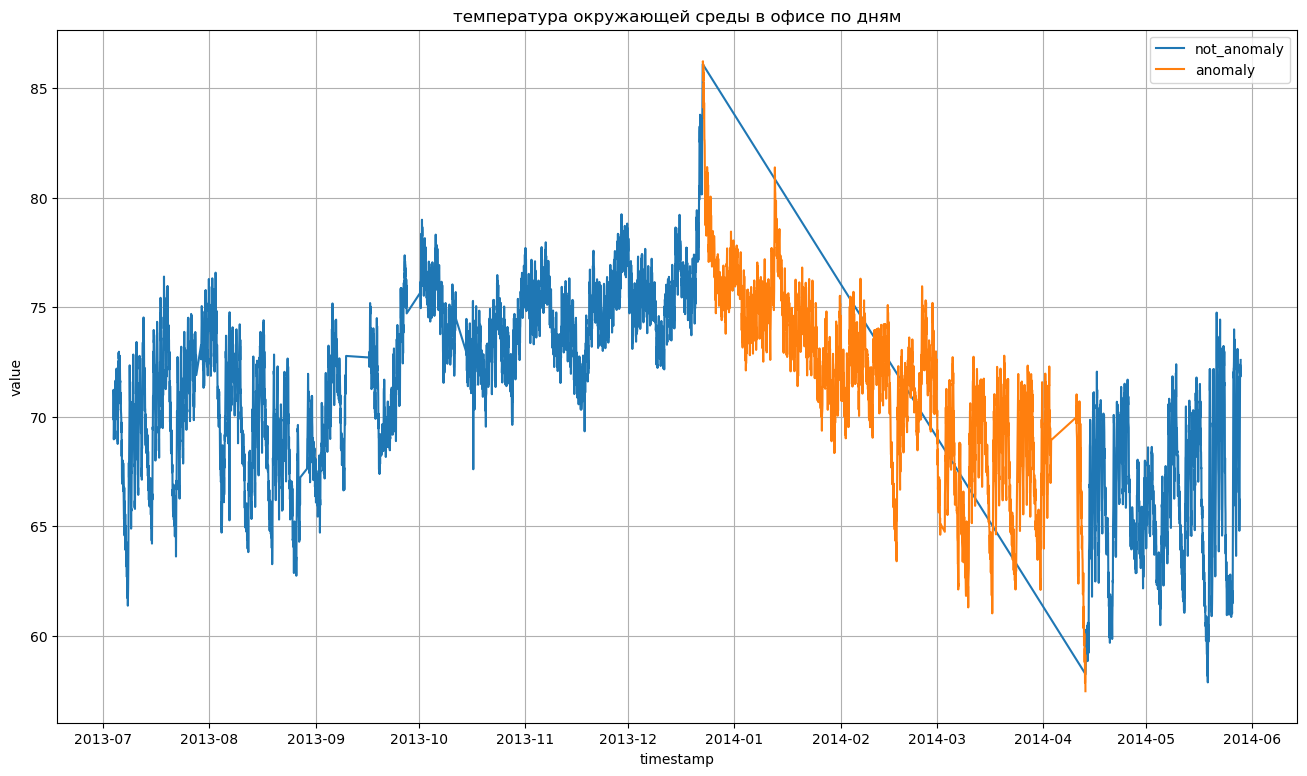

In [229]:
plt.figure(figsize=(16,9))

plt.title('температура окружающей среды в офисе по дням')
sns.lineplot(ambient_temp_df.loc[ambient_temp_df['anomaly'] == 0], y = 'value', x= 'timestamp', label = 'not_anomaly')
sns.lineplot(ambient_temp_df.loc[ambient_temp_df['anomaly'] != 0], y = 'value', x= 'timestamp', label = 'anomaly')
plt.grid()
plt.show()

В данном временном ряде также хорошо прослеживается повторяющеися поведение, и более ярко выражен тренд

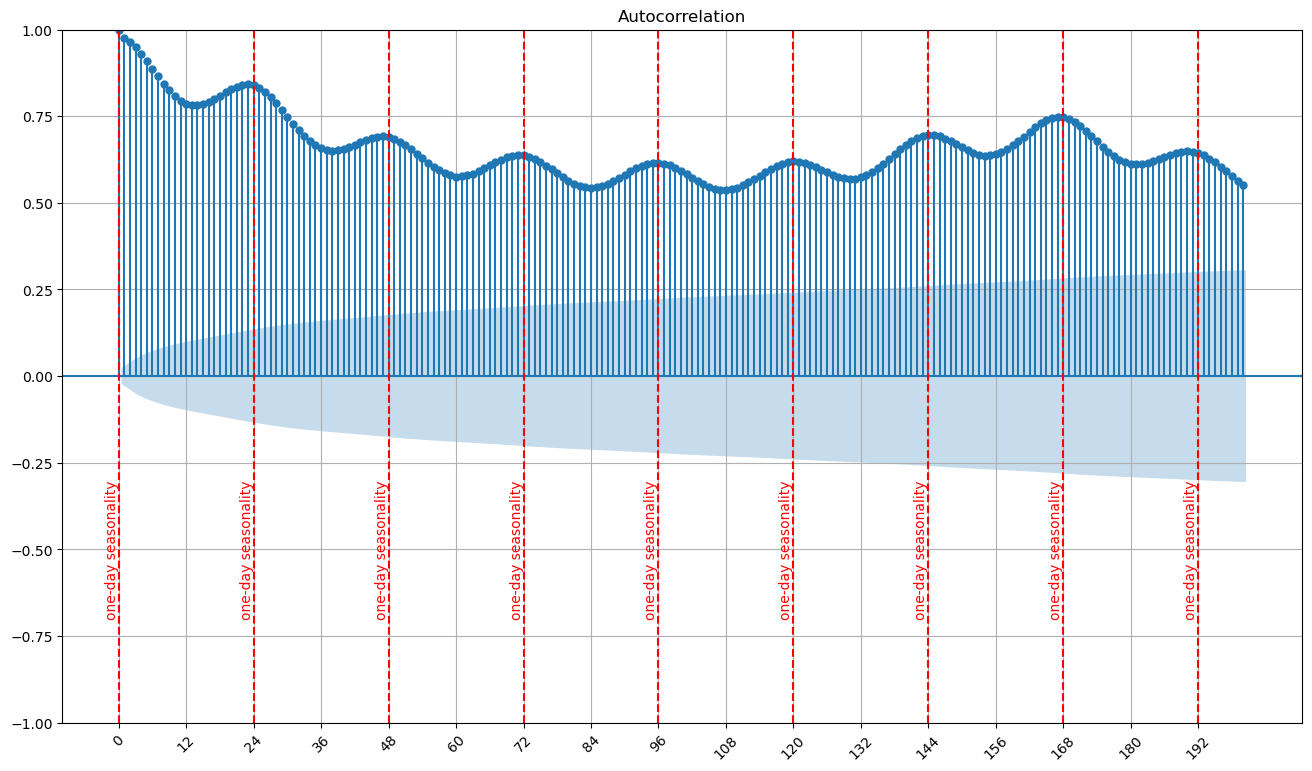

In [232]:
fig, ax = plt.subplots(figsize=(16, 9))
plot_acf(ambient_temp_df["value"], lags=200, ax=ax)

ax.set_xticks(range(0, 201, 12))
ax.tick_params(axis='x', rotation=45)
ax.grid(True)
lags = [x for x in range(0,201, 24)]
for lag in lags:
    ax.axvline(x=lag, color='red', linestyle='--', linewidth=1.5, label = 'season_component')
    ax.text(
        lag, 
        -0.5, 
        'one-day seasonality',
        rotation=90,
        color='red',
        ha='right',
        va='center'
    )

plt.show()

В этом наборе данных наблюдаем 24 часовую сезонность

In [233]:
#Применим STL разложение
stl = STL(ambient_temp_df["value"], period=24, robust = True)
result = stl.fit()
ambient_temp_df["trend"] = result.trend
ambient_temp_df["seasonal"] = result.seasonal
ambient_temp_df["resid"] = result.resid

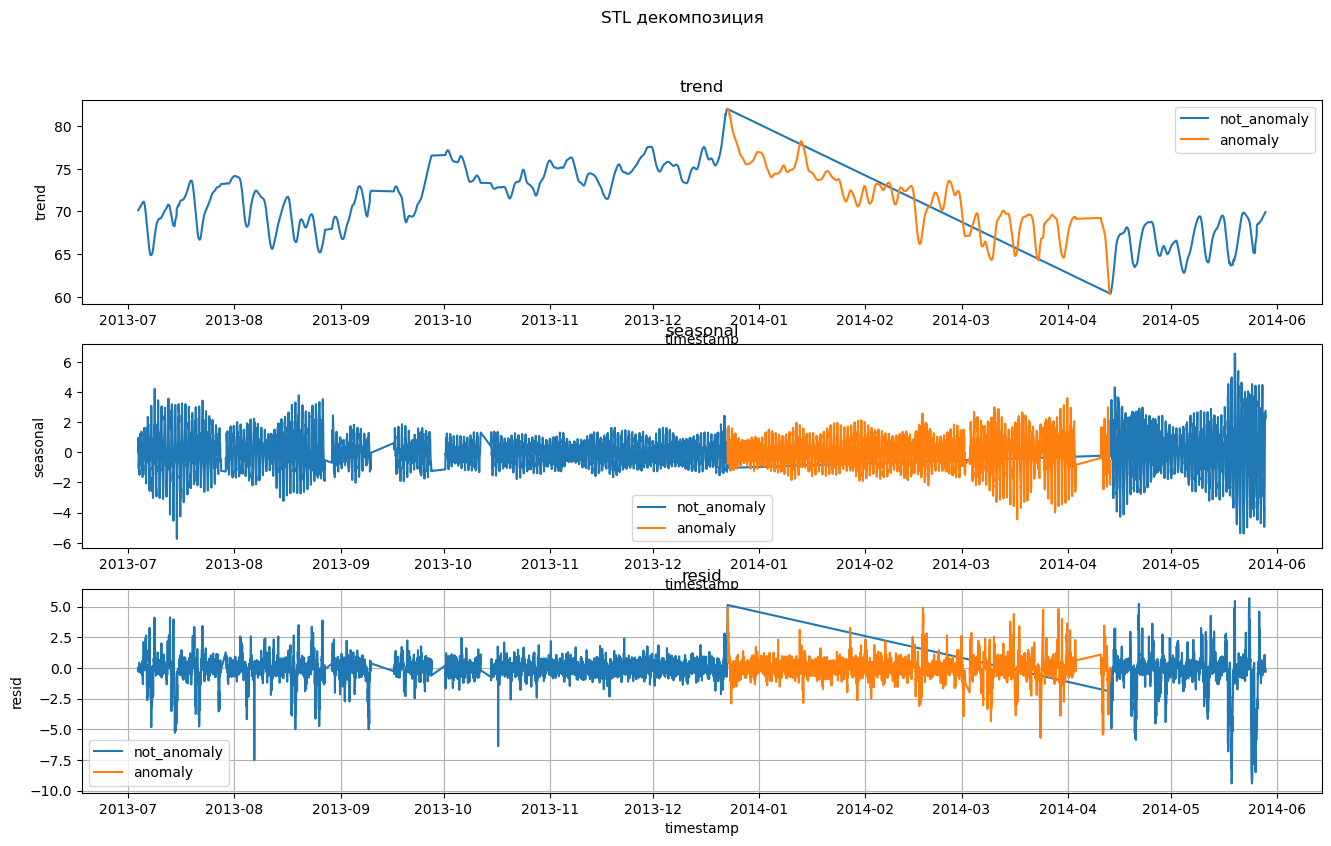

In [234]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9))
plt.suptitle('STL декомпозиция')
for ax, name in zip(axes, ['trend', 'seasonal', 'resid']):
    ax.set_title(name)
    sns.lineplot(ambient_temp_df.loc[ambient_temp_df['anomaly'] == 0],
                 x = 'timestamp', y = name, label = 'not_anomaly', ax = ax)
    sns.lineplot(ambient_temp_df.loc[ambient_temp_df['anomaly'] != 0],
                 x = 'timestamp', y = name, label = 'anomaly', ax = ax)
plt.legend()
plt.grid()

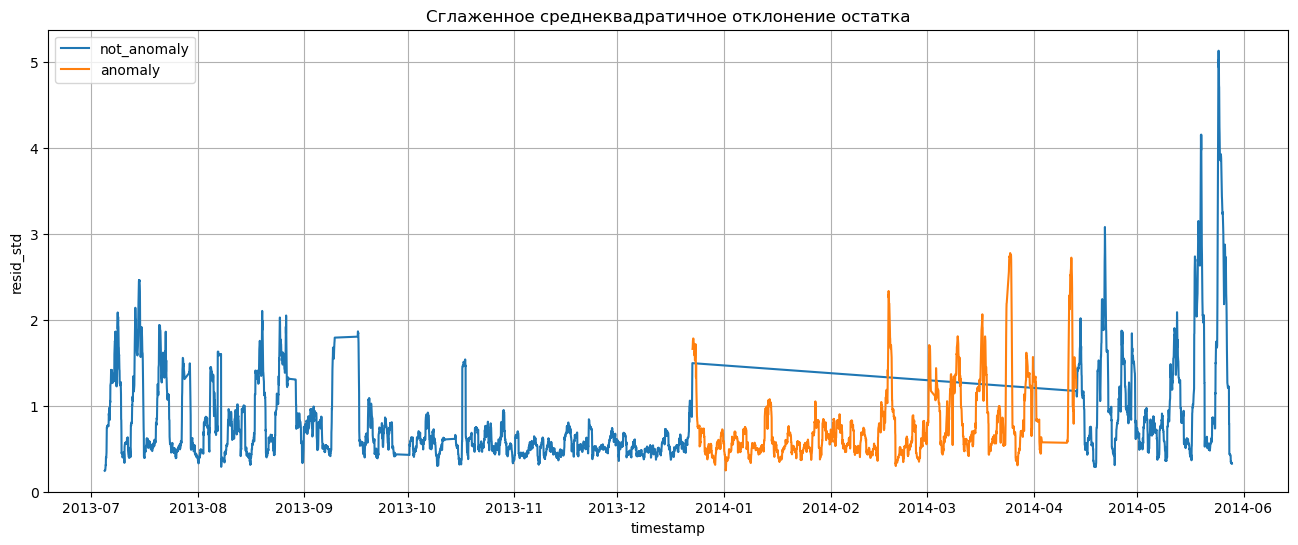

In [236]:
ambient_temp_df["resid_std"] = ambient_temp_df["resid"].rolling(24).std()

plt.figure(figsize=(16,6))
plt.title('Сглаженное среднеквадратичное отклонение остатка')
sns.lineplot(ambient_temp_df.loc[ambient_temp_df['anomaly'] ==0],
             x = 'timestamp', y = 'resid_std', label = 'not_anomaly')
sns.lineplot(ambient_temp_df.loc[ambient_temp_df['anomaly'] ==1],
             x = 'timestamp', y = 'resid_std', label = 'anomaly')
plt.grid()
plt.show()

Анализ трендовой компоненты показал, что часть аномалий проявляется не как локальные выбросы, а как изменение формы тренда. В частности, наблюдаются участки, где динамика показателя отклоняется от ожидаемого поведения и формирует аномальный участок с постепенным изменением уровня. Такие аномалии не всегда выделяются в остаточной компоненте STL, поскольку частично интерпретируются моделью как изменение тренда. Это указывает на необходимость учета не только остаточной компоненты, но и динамики тренда при построении алгоритмов обнаружения аномалий.

## Набор данных: данные мониторинга использования ЦП в Amazon Web Services (AWS)

In [238]:
cpu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18050 entries, 0 to 18049
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  18050 non-null  object 
 1   value      18050 non-null  float64
dtypes: float64(1), object(1)
memory usage: 282.2+ KB


In [239]:
#Приведем колонки к timestamp
cpu_df['timestamp'] = pd.to_datetime(cpu_df['timestamp'])

In [241]:
#добавим labels
with open('/Users/dmitry/Desktop/HSE_mag/Magister/Data/NAB/labels/combined_labels.json') as f:
    labels = json.load(f)

labels['realKnownCause/cpu_utilization_asg_misconfiguration.csv']

cpu_df['anomaly'] = 0

for i in range(0, len(labels['realKnownCause/cpu_utilization_asg_misconfiguration.csv']) - 1, 2):
    start = labels['realKnownCause/cpu_utilization_asg_misconfiguration.csv'][i]
    end = labels['realKnownCause/cpu_utilization_asg_misconfiguration.csv'][i+1]

    mask = ((cpu_df['timestamp'] <= end) & (cpu_df['timestamp'] >= start))
    cpu_df.loc[mask, 'anomaly'] = 1
    
        

In [243]:
print(f'Процент аномалий в датасэте {np.round(cpu_df['anomaly'].sum() / cpu_df.shape[0] * 100, 2)} %')

Процент аномалий в датасэте 4.5 %


In [245]:
cpu_df.describe()

,timestamp,value,anomaly
count,18050,18050.000000,18050.000000
mean,2014-06-14 09:16:30,38.282756,0.045042
min,2014-05-14 01:14:00,11.529000,0.000000
25%,2014-05-29 17:15:15,30.789000,0.000000
50%,2014-06-14 09:16:30,32.001000,0.000000
75%,2014-06-30 01:17:45,35.660500,0.000000
max,2014-07-15 17:19:00,100.000000,1.000000
std,NaN,15.639294,0.207401


In [247]:
cpu_df.duplicated().sum()

0

В данном датасэте также проблем с данными не выявлено

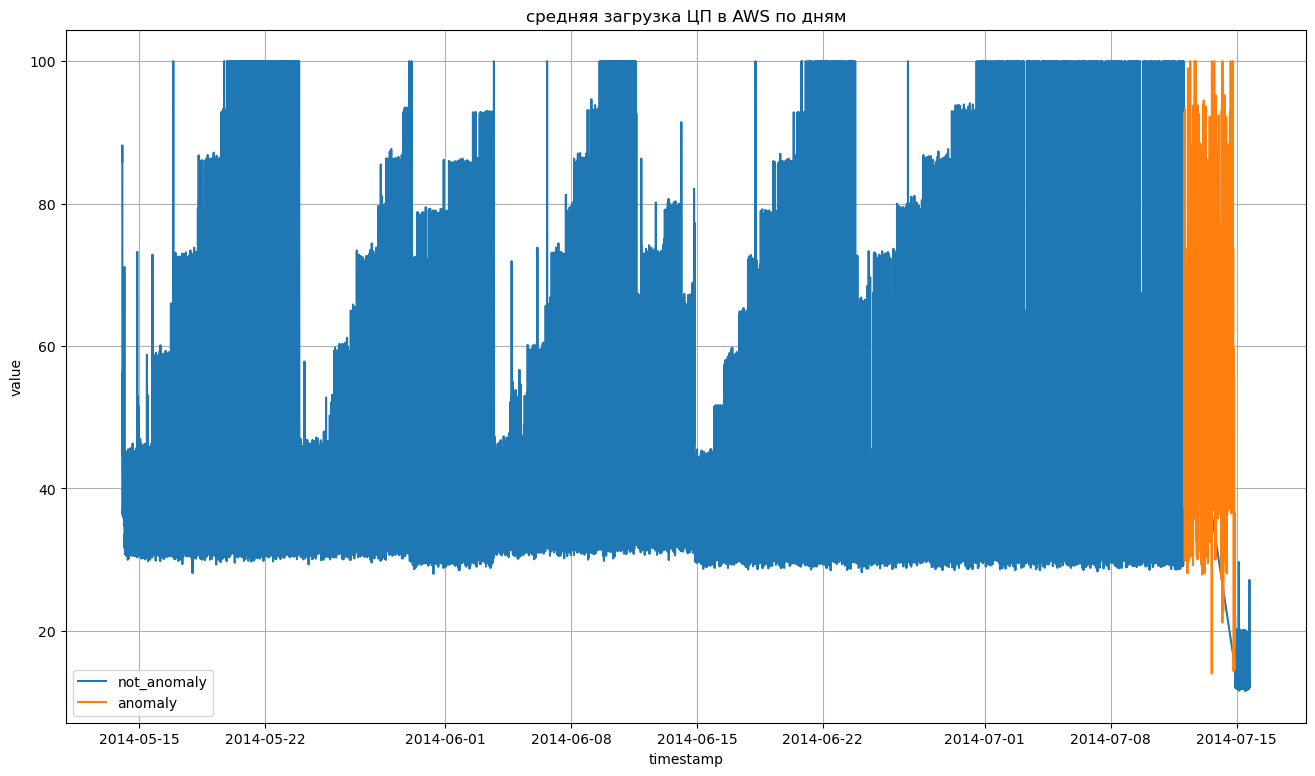

In [249]:
plt.figure(figsize=(16,9))

plt.title('средняя загрузка ЦП в AWS по дням')
sns.lineplot(cpu_df.loc[cpu_df['anomaly'] == 0], y = 'value', x= 'timestamp', label = 'not_anomaly')
sns.lineplot(cpu_df.loc[cpu_df['anomaly'] != 0], y = 'value', x= 'timestamp', label = 'anomaly')
plt.grid()
plt.show()

В данном временном ряде  хорошо прослеживается повторяющеися поведение

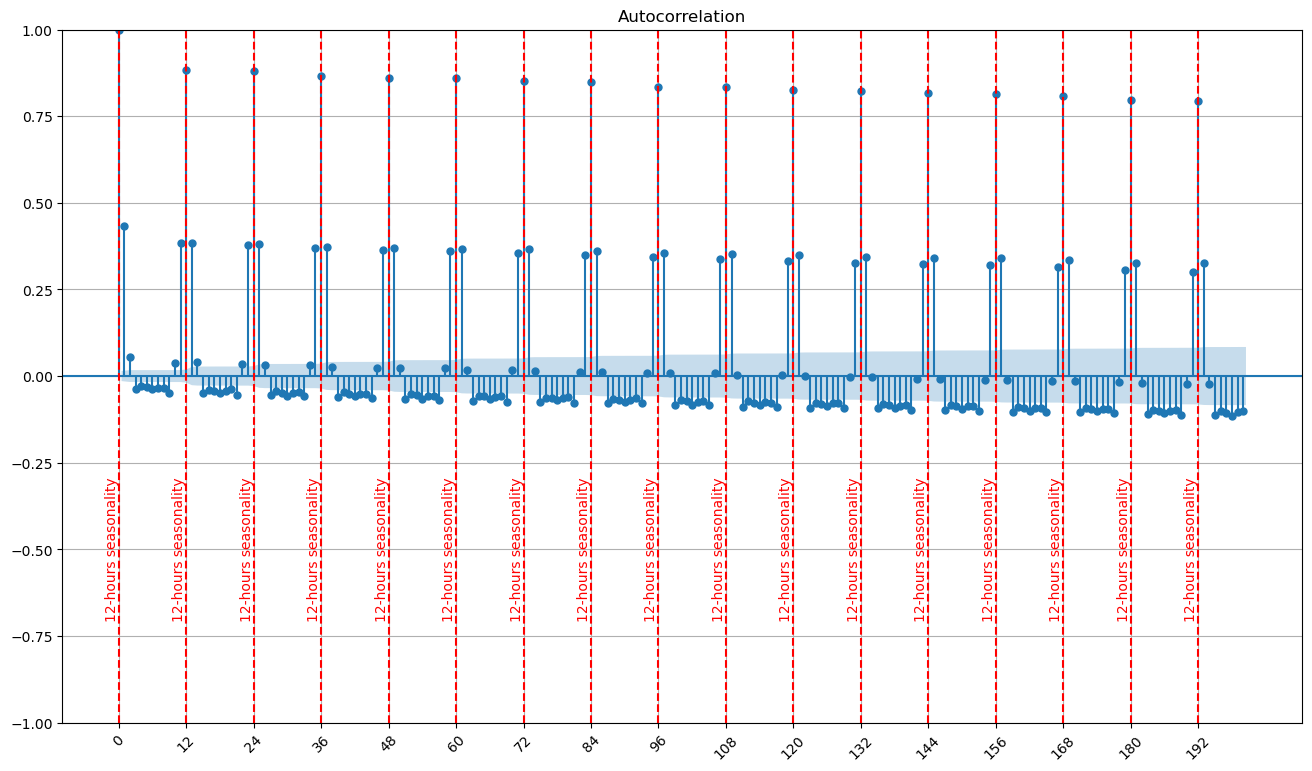

In [254]:
fig, ax = plt.subplots(figsize=(16, 9))
plot_acf(cpu_df["value"], lags=200, ax=ax)

ax.set_xticks(range(0, 201, 12))
ax.tick_params(axis='x', rotation=45)
ax.grid(True)
lags = [x for x in range(0,201, 12)]
for lag in lags:
    ax.axvline(x=lag, color='red', linestyle='--', linewidth=1.5, label = 'season_component')
    ax.text(
        lag, 
        -0.5, 
        '12-hours seasonality',
        rotation=90,
        color='red',
        ha='right',
        va='center'
    )

plt.show()

В этом наборе данных наблюдаем 12 часовую сезонность

In [255]:
#Применим STL разложение
stl = STL(cpu_df["value"], period=12, robust = True)
result = stl.fit()
cpu_df["trend"] = result.trend
cpu_df["seasonal"] = result.seasonal
cpu_df["resid"] = result.resid

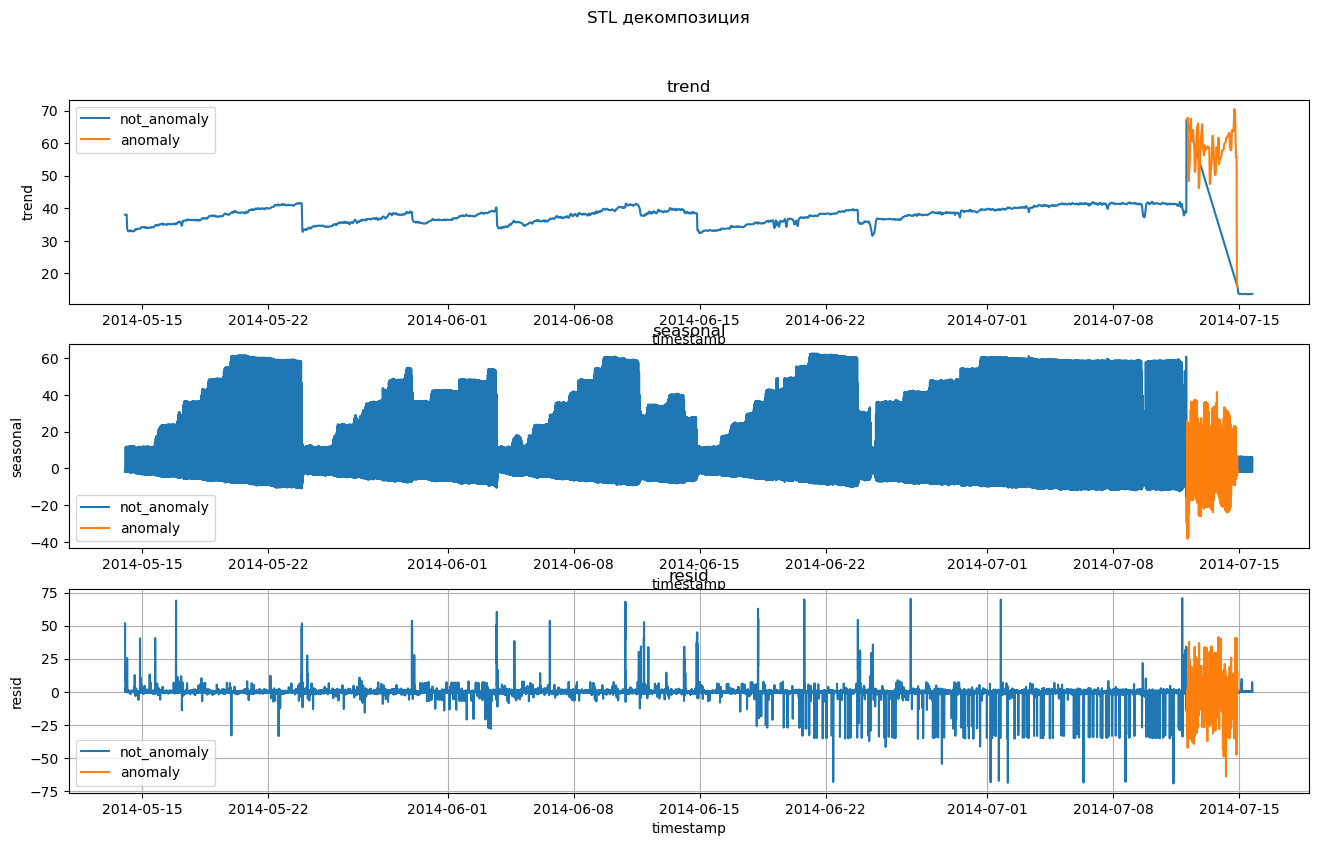

In [256]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9))
plt.suptitle('STL декомпозиция')
for ax, name in zip(axes, ['trend', 'seasonal', 'resid']):
    ax.set_title(name)
    sns.lineplot(cpu_df.loc[cpu_df['anomaly'] == 0],
                 x = 'timestamp', y = name, label = 'not_anomaly', ax = ax)
    sns.lineplot(cpu_df.loc[cpu_df['anomaly'] != 0],
                 x = 'timestamp', y = name, label = 'anomaly', ax = ax)
plt.legend()
plt.grid()

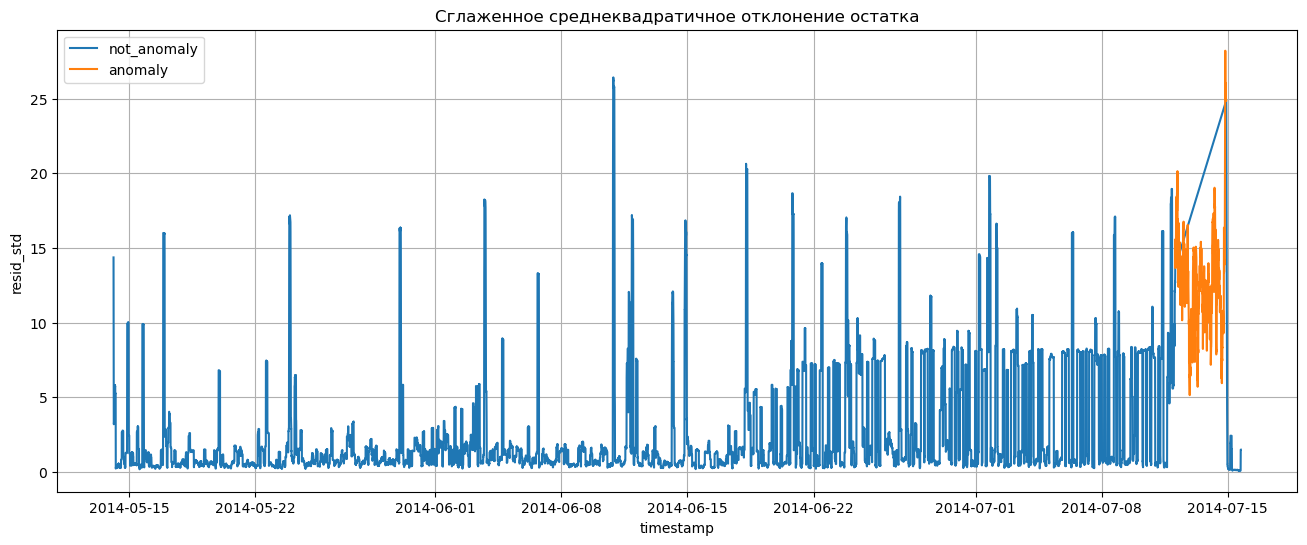

In [258]:
cpu_df["resid_std"] = cpu_df["resid"].rolling(24).std()

plt.figure(figsize=(16,6))
plt.title('Сглаженное среднеквадратичное отклонение остатка')
sns.lineplot(cpu_df.loc[cpu_df['anomaly'] ==0],
             x = 'timestamp', y = 'resid_std', label = 'not_anomaly')
sns.lineplot(cpu_df.loc[cpu_df['anomaly'] ==1],
             x = 'timestamp', y = 'resid_std', label = 'anomaly')
plt.grid()
plt.show()

В рассматриваемом случае аномалии проявляются в виде значительного увеличения дисперсии остаточной компоненты после STL-декомпозиции. В нормальных условиях остаток представляет собой шум с малой амплитудой, тогда как в аномальных интервалах наблюдается существенное увеличение разброса значений. Это позволяет эффективно выявлять аномалии на основе анализа локальных статистик остатка, таких как скользящее стандартное отклонение.

#### Анализ датасета показал, что временной ряд имеет выраженную сезонную структуру и изменяющийся во времени уровень значений. Аномалии в нём проявляются по-разному: в одних случаях как выбросы в остаточной компоненте, в других — как изменение тренда или нарушение регулярного поведения ряда. Таким образом, исследуемый датасет подтверждает, что задача обнаружения аномалий не может быть решена только за счёт фиксированного порога по исходным значениям. Для повышения точности детекции необходимо учитывать декомпозицию ряда, сезонность и локальные статистические характеристики.